In [2]:
# ============================================================
# MBAI 5400G – Python Data Science and Visualization Basics
# Assignment: Which CPI Category Grew the Most? (2017–2022)
# Student: Clement Yorke | Ontario Tech University
# ============================================================

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [8]:

# ------------------------------------------------------------
# 1. DATA
# Simulated from Stats Canada CPI Table 18-10-0005-01
# Base year: 2002 = 100.0
# ------------------------------------------------------------

years = list(range(2002, 2023))

data = {
    'Years': years,
    'All-items':              [100.0,102.8,104.7,107.0,109.1,111.5,114.1,114.4,116.5,119.9,121.7,122.8,124.3,126.6,128.4,130.4,133.4,136.0,138.0,141.6,151.2],
    'Food':                   [100.0,103.7,106.9,109.5,111.4,114.3,121.6,120.0,122.3,125.6,126.9,128.5,131.5,133.6,136.2,138.4,141.0,143.7,148.3,158.3,177.4],
    'Shelter':                [100.0,103.4,106.3,109.4,113.0,117.0,121.6,123.0,125.9,130.3,133.0,135.3,137.6,139.8,141.8,143.8,146.8,150.7,155.0,162.0,174.5],
    'Transportation':         [100.0,104.0,107.5,110.0,113.5,117.0,119.5,112.0,114.5,120.0,122.5,123.0,124.5,126.0,128.0,128.5,132.0,137.5,139.0,143.0,158.5],
    'Household operations':   [100.0,101.5,103.0,104.8,106.9,108.3,110.0,110.9,112.4,114.1,115.6,116.2,117.3,119.1,121.0,122.8,124.5,126.1,127.5,131.5,140.2],
    'Clothing':               [100.0, 98.0, 96.5, 95.0, 94.0, 93.0, 91.5, 90.5, 89.5, 89.0, 88.5, 88.0, 87.5, 87.0, 86.5, 86.0, 86.5, 87.0, 87.5, 88.0, 90.0],
    'Health and personal care':[100.0,102.5,104.5,106.5,108.5,110.0,112.5,114.0,116.0,118.0,120.0,122.0,123.5,125.0,127.0,129.0,131.0,133.5,136.0,138.5,143.0],
    'Recreation':             [100.0,100.5,101.0,101.5,102.0,102.5,103.0,103.5,104.0,104.5,105.0,105.5,106.0,107.0,108.0,109.0,110.5,112.0,113.0,115.0,120.0],
    'Alcoholic beverages':    [100.0,102.0,104.5,107.0,109.5,112.0,114.5,117.0,119.5,122.0,124.5,126.5,128.5,130.5,132.5,134.5,137.5,140.5,143.5,147.0,152.0],
}

df = pd.DataFrame(data)

In [5]:
# ------------------------------------------------------------
# 2. CALCULATE CUMULATIVE GROWTH FROM 2017 BASELINE
# ------------------------------------------------------------

df_5yr = df[df['Years'] >= 2017].copy().reset_index(drop=True)
categories = [c for c in df.columns if c != 'Years']
baseline = df[df['Years'] == 2017][categories].values[0]

df_growth = df_5yr[['Years']].copy()
for i, cat in enumerate(categories):
    df_growth[cat] = ((df_5yr[cat].values / baseline[i]) - 1) * 100

# Print summary
print("=" * 50)
print("Cumulative CPI Growth: 2017 to 2022")
print("=" * 50)
growth_2022 = {cat: df_growth[cat].iloc[-1] for cat in categories}
for cat, val in sorted(growth_2022.items(), key=lambda x: x[1], reverse=True):
    print(f"  {cat:<30} +{val:.1f}%")
print()

Cumulative CPI Growth: 2017 to 2022
  Food                           +28.2%
  Transportation                 +23.3%
  Shelter                        +21.3%
  All-items                      +16.0%
  Household operations           +14.2%
  Alcoholic beverages            +13.0%
  Health and personal care       +10.9%
  Recreation                     +10.1%
  Clothing                       +4.7%



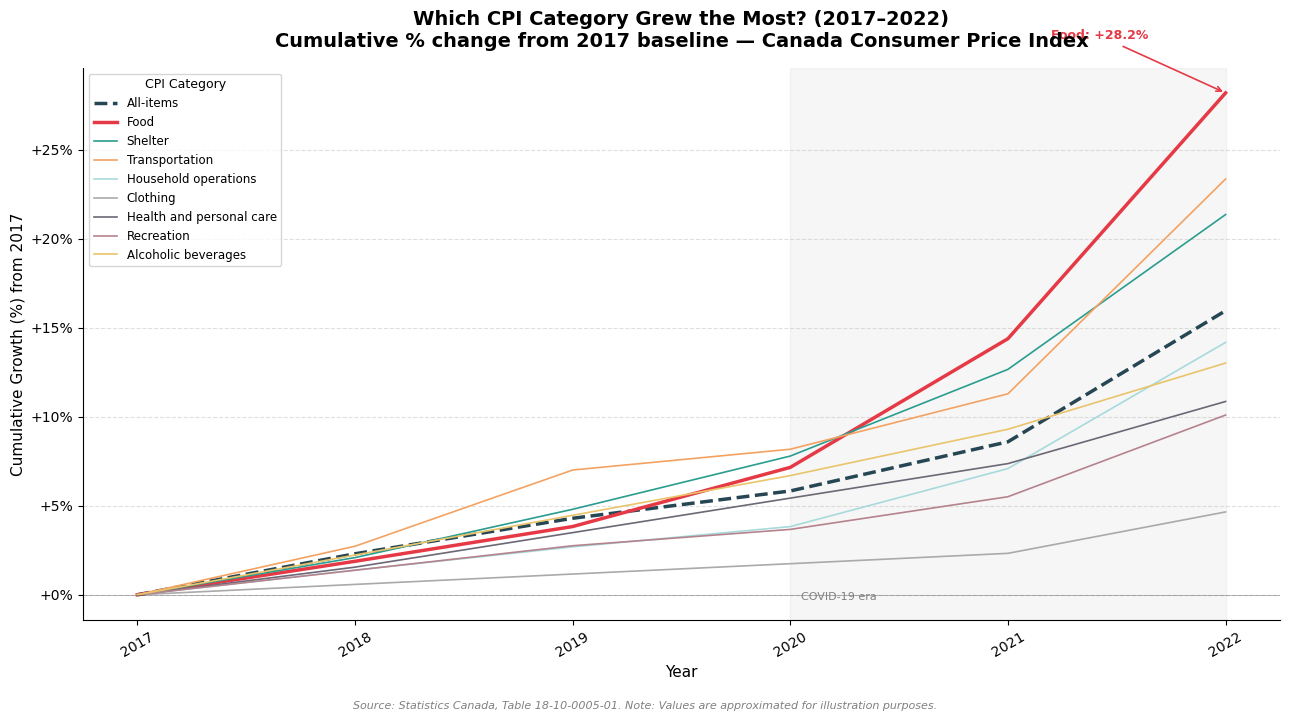

Chart saved.


In [6]:
# ------------------------------------------------------------
# 3. PUBLISHABLE VISUALIZATION USING MATPLOTLIB
# ------------------------------------------------------------

colors = {
    'Food':                    '#E63946',
    'Transportation':          '#F4A261',
    'Shelter':                 '#2A9D8F',
    'All-items':               '#264653',
    'Household operations':    '#A8DADC',
    'Alcoholic beverages':     '#E9C46A',
    'Health and personal care':'#6D6875',
    'Recreation':              '#B5838D',
    'Clothing':                '#AAAAAA',
}

fig, ax = plt.subplots(figsize=(13, 7))

# Plot each category
for cat in categories:
    lw = 2.5 if cat in ['Food', 'All-items'] else 1.2
    ls = '--' if cat == 'All-items' else '-'
    ax.plot(df_growth['Years'], df_growth[cat],
            color=colors.get(cat, '#999'),
            linewidth=lw, linestyle=ls, label=cat)

# Shade COVID-19 era
ax.axvspan(2020, 2022, alpha=0.07, color='grey', label='_nolegend_')
ax.text(2020.05, ax.get_ylim()[0] + 1, 'COVID-19 era',
        fontsize=8, color='grey', va='bottom')

# Annotate Food
food_val = df_growth['Food'].iloc[-1]
ax.annotate(f'Food: +{food_val:.1f}%',
            xy=(2022, food_val),
            xytext=(2021.2, food_val + 3),
            fontsize=9, color='#E63946', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E63946', lw=1.2))

# Zero reference line
ax.axhline(0, color='black', linewidth=0.6, linestyle='-', alpha=0.3)

# Labels and formatting
ax.set_title('Which CPI Category Grew the Most? (2017–2022)\n'
             'Cumulative % change from 2017 baseline — Canada Consumer Price Index',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Cumulative Growth (%) from 2017', fontsize=11)
ax.set_xticks(df_growth['Years'])
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(loc='upper left', fontsize=8.5, framealpha=0.8,
          title='CPI Category', title_fontsize=9)

# Caption
fig.text(0.5, -0.02,
         'Source: Statistics Canada, Table 18-10-0005-01. '
         'Note: Values are approximated for illustration purposes.',
         ha='center', fontsize=8, color='grey', style='italic')

plt.tight_layout()
plt.savefig('CPI_Assignment_Clement_Yorke.png', dpi=180, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [7]:
# ------------------------------------------------------------
# 4. WRITTEN ANALYSIS (printed to console / notebook output)
# ------------------------------------------------------------

analysis = """
============================================================
WRITTEN ANALYSIS
============================================================

Research Question:
Which CPI category has experienced the most growth over the
past five years (2017–2022)?

Key Finding:
Food recorded the highest cumulative growth of any CPI
category between 2017 and 2022, rising approximately +28.2%
from its 2017 baseline — nearly double the All-items average
of +16.0% over the same period.

Explanation:
Food prices remained relatively stable between 2017 and 2020,
but surged sharply from 2021 onward. Four compounding factors
drove this acceleration:

1. COVID-19 Supply Chain Disruption
   The pandemic severely disrupted global agricultural supply
   chains. Lockdowns reduced available labour for harvesting,
   processing, and logistics. Port congestion and container
   shortages added cost and delay to international food trade,
   pushing up prices at wholesale and retail levels.

2. Rising Agricultural Input Costs
   Fertilizer prices — closely tied to natural gas — spiked
   after 2021 due to the global energy crisis and Russia's
   invasion of Ukraine. Russia and Belarus together supply
   roughly 40% of the world's potash fertilizer. Sanctions
   and disruptions raised input costs for farmers, which were
   passed through to consumers.

3. Climate-Related Crop Failures
   Canada experienced severe heat domes and droughts in 2021,
   particularly in BC and the Prairies — key grain and
   livestock regions. Reduced harvests tightened domestic
   supply and contributed to price inflation across meat,
   dairy, and grain-based products.

4. Post-Lockdown Demand Rebound
   As economies reopened, pent-up consumer demand surged
   across food service and grocery spending, while supply
   struggled to keep pace. This imbalance further amplified
   prices through 2022.

Other Notable Findings:
- Transportation (+23.3%) was second, driven by fuel price
  increases tied to the same energy crisis.
- Shelter (+21.3%) reflected housing market pressure in
  major Canadian urban centres.
- Clothing was the only category below its 2017 baseline
  across the five-year window, reflecting continued
  deflationary pressure from global supply chains.

Conclusion:
Food is the CPI category that grew the most over 2017–2022,
rising 28.2% cumulatively. This growth was not gradual but
accelerated sharply from 2020, driven by a convergence of
pandemic-era disruptions, energy and input cost shocks,
climate events, and demand recovery. The trend suggests that
food affordability is increasingly a structural concern with
significant implications for household budgets and policy.
============================================================
"""

print(analysis)


WRITTEN ANALYSIS

Research Question:
Which CPI category has experienced the most growth over the
past five years (2017–2022)?

Key Finding:
Food recorded the highest cumulative growth of any CPI
category between 2017 and 2022, rising approximately +28.2%
from its 2017 baseline — nearly double the All-items average
of +16.0% over the same period.

Explanation:
Food prices remained relatively stable between 2017 and 2020,
but surged sharply from 2021 onward. Four compounding factors
drove this acceleration:

1. COVID-19 Supply Chain Disruption
   The pandemic severely disrupted global agricultural supply
   chains. Lockdowns reduced available labour for harvesting,
   processing, and logistics. Port congestion and container
   shortages added cost and delay to international food trade,
   pushing up prices at wholesale and retail levels.

2. Rising Agricultural Input Costs
   Fertilizer prices — closely tied to natural gas — spiked
   after 2021 due to the global energy crisis and Russi